<a href="https://colab.research.google.com/github/Medder001/ML-Final/blob/main/ML_Final_Kay%26Megan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
DRIVE_PATH = "/content/drive/MyDrive/archive"


Mounted at /content/drive


In [2]:
import os
import numpy as np
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import time
import seaborn as sns

In [3]:
# Load images in a consistent format
# Stop load if sample becomes too large
# Skip bad data
def load_images(folder, label, img_size=(64, 64), max_images=1000):
  data = []
  filenames = os.listdir(folder)
  np.random.shuffle(filenames)
  count = 0
  for fname in filenames:
    if count >= max_images:
      break
    try:
      img = Image.open(os.path.join(folder, fname)).convert('RGB')
      img = img.resize(img_size)
      pixels = np.array(img)
      data.append({'pixels': pixels, 'label':label})
      count += 1
    except Exception:
      pass
  return data

In [5]:
ai_data = load_images("/content/drive/MyDrive/archive/AiArtData/AiArtData", label=1)
real_data = load_images("/content/drive/MyDrive/archive/RealArt/RealArt", label = 0)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [6]:
df = pd.DataFrame(ai_data + real_data)

X = np.stack(df['pixels'].values)
y = df['label'].values

In [7]:
print(f"Total instance: {len(df)}")
print(df['label'].value_counts())

size_mb = df['pixels'].apply(lambda x: x.nbytes).sum() / (1024 * 1024)
print(f"Loaded data size: {size_mb:.2f} MB")


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = X_train / 255.0
X_test = X_test / 255.0

print(X.shape)
print(X.dtype)

Total instance: 949
label
1    526
0    423
Name: count, dtype: int64
Loaded data size: 11.12 MB
(949, 64, 64, 3)
uint8


Our dataset is sampled for an AI-generated image detector ML model from Kaggle (https://www.kaggle.com/datasets/cashbowman/ai-generated-images-vs-real-images).
We sample up to 1,000 images per class with a result of 975 image instances in our dataset, specifically 539 AI-generated images and 436 real images. The images are resized to 64x64 and formatted as 'RGB'. From this, the calculated number of numeric attributes is 64 * 64 * 3 = 12,288 which are normalized to a continuous range of [0,1]. Additonally, any corrupted files are passed over.

In [8]:
# This data is used in the RandomForestClassifier model to compare against CNN
# The CNN needs our data to have dimensionality
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape", X_test_flat.shape)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_flat)

X_test_pca = pca.transform(X_test_flat)

print("Reduced shape:", X_train_pca.shape)
print("Variance retained:", pca.explained_variance_ratio_.sum())
print("Number of components:", pca.n_components_)

X_train_flat shape: (759, 12288)
X_test_flat shape (190, 12288)
Reduced shape: (759, 311)
Variance retained: 0.9501966105386593
Number of components: 311


We used scikit-learn to implement PCA on our image data. Each image in both sets was flattened into a single vector of 12,288 features. The training set was fit, and both sets were transformed. We were able to reduce the 12,288 features to 313 with a 95% variance retention. This data is utilized within the Random Forest Classifier to compare against our CNN model resutls.

In [9]:
# You will have to run this before you train every time or it will train the
# already trained model.

model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,289 (1.48 MB)

 Trainable params: 388,289 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

The CNN takes 64x64 RGB images as input. Next, data augmentation techniques such as horrizontal flipping, rotation, and zooming are preformed on the images to prevent the model from overfitting. After this the data is sent through three convolutional layers, each followed by a max pooling layer to help the model learn  distinguishing features such as edges and textures while shrinking the data and keeping the most prominent features. The output is then flattened and sent into a dense layer with 64 units followed by a dropout layer to improve generalization. Finally, the data flows through a sigmoid output neuron for binary classification between AI generated artwork and real artwork.


In [10]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=28,
    validation_split=0.15,
    callbacks=[early_stopping]
)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 217ms/step - accuracy: 0.5566 - loss: 0.6945 - val_accuracy: 0.5351 - val_loss: 0.6849
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 241ms/step - accuracy: 0.5566 - loss: 0.6877 - val_accuracy: 0.5351 - val_loss: 0.6856
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.5535 - loss: 0.6752 - val_accuracy: 0.5877 - val_loss: 0.6626
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step - accuracy: 0.5829 - loss: 0.6726 - val_accuracy: 0.5877 - val_loss: 0.6605
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 232ms/step - accuracy: 0.5829 - loss: 0.6706 - val_accuracy: 0.5789 - val_loss: 0.6701
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 370ms/step - accuracy: 0.5643 - loss: 0.6729 - val_accuracy: 0.5351 - val_loss: 0.6994
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - accuracy: 0.5581 - loss: 0.6621 - val_accuracy: 0.5439 - val_loss: 0.6638


The model is trained using our training data for up to 20 epochs with a batch size of 28. 15% of the training data is set aside to evaluate the models performace durring training through the validation split parameter. The Early stopping callback is included to monitor the validation loss during training. If the validation loss does not improve within 3 epochs the training will be stopped early to prevent overfitting. Additionally, early stopping will restore the best weights to keep the best possible model outcome.

In [11]:
val_loss, val_acc = model.evaluate(X_test, y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6053 - loss: 0.6543


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


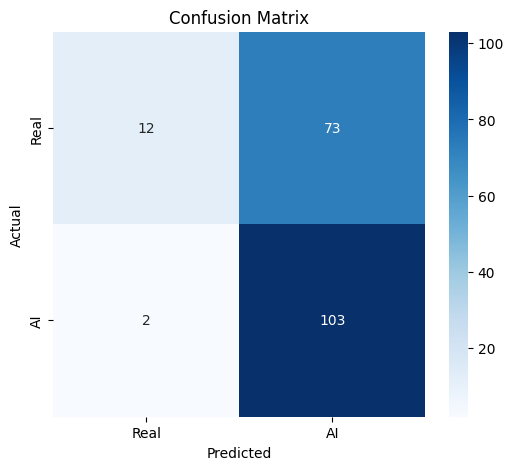

              precision    recall  f1-score   support

        Real       0.86      0.14      0.24        85
          AI       0.59      0.98      0.73       105

    accuracy                           0.61       190
   macro avg       0.72      0.56      0.49       190
weighted avg       0.71      0.61      0.51       190

Prediction time: 0.701 seconds


In [12]:
start = time.time()
y_pred_probs = model.predict(X_test)
end = time.time()
y_pred = (y_pred_probs > 0.5).astype(int).ravel()


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'AI'],
            yticklabels=['Real', 'AI'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Real', 'AI']))
print(f"Prediction time: {end - start:.3f} seconds")

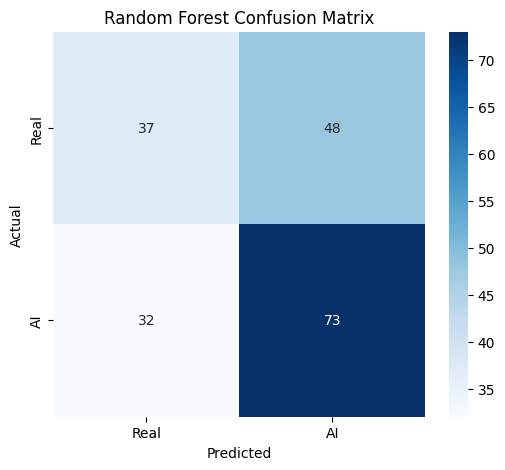

              precision    recall  f1-score   support

        Real       0.54      0.44      0.48        85
          AI       0.60      0.70      0.65       105

    accuracy                           0.58       190
   macro avg       0.57      0.57      0.56       190
weighted avg       0.57      0.58      0.57       190

Training time: 1.540 seconds
Prediction time: 0.010 seconds


In [13]:
#Small Simple Classifier on PCA-reduced data for comparison
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_pca, y_train)
train_time = time.time() - start

start = time.time()
y_pred_rf = rf.predict(X_test_pca)
pred_time = time.time() - start

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'AI'],
            yticklabels=['Real', 'AI'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_rf, target_names=['Real', 'AI']))
print(f"Training time: {train_time:.3f} seconds")
print(f"Prediction time: {pred_time:.3f} seconds")

From the data, we can tell that CNN is more accurate than the RF model with 69% vs 63% accuracy, respectively However, the RF model is faster than CNN.

CNN and RF perform with 46% recall on real images which is significantly less than the 76-88% recall on the AI images. This indicates there is a limitation in distinguishing real images within our data set. This could be caused by the imbalance of set sizes between the two, as we started with more AI images, but it is likely due to the difficult problem model that we selected.

In [ ]:
plt.figure(figsize = (10, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

The largest issue that we encountered was due to the size of our dataset. Both models were relatively close with the results from the confusion matrix, indicating that the results were consistent across multiple types of models. We attempted to increase the accuracy by adding data augmentation that effectively made the dataset more varied by showing slightly different versions of each image within each epoch. Additionally, the EarlyStopping callback prevents overfitting of the data. We attempted to increase the size of the images to 128x128 to see if this improved our results, but it decreased performance and slowed the training down significantly.

If we could change the way that we attempted this project, we would use a larger dataset (disregarding the project rubric constraint), which would allow more variety within the images which could improve the performance. Using a larger dataset would close the gap between the validation and test accuracies.